AlexNet

In [15]:
import tensorflow as tf
from d2l import tensorflow as d2l


def net():
    return tf.keras.models.Sequential([
        # Burada nesneleri yakalamak için daha büyük bir 11 x 11'lik pencere kullanıyoruz.
        # Aynı zamanda, çıktının yüksekliğini ve genişliğini büyük ölçüde azaltmak
        # için 4'lük bir uzun adım kullanıyoruz. Burada, çıktı kanallarının sayısı
        # LeNet'tekinden çok daha fazladır.
        tf.keras.layers.Conv2D(filters=96, kernel_size=11, strides=4,
                               activation='relu'),
        tf.keras.layers.MaxPool2D(pool_size=3, strides=2),
        # Evrişim penceresini küçült, girdi ve çıktı boyunca tutarlı yükseklik
        # ve genişlik için dolguyu 2'ye ayarlayın ve çıktı kanallarının sayısını artırın
        tf.keras.layers.Conv2D(filters=256, kernel_size=5, padding='same',
                               activation='relu'),
        tf.keras.layers.MaxPool2D(pool_size=3, strides=2),
        # Ardışık üç evrişim katmanı ve daha küçük bir evrişim penceresi kullan.
        # Son evrişim katmanı dışında, çıktı kanallarının sayısı daha da artırılır.
        # Ortaklama katmanları, ilk iki evrişim katmanından sonra girdinin
        # yüksekliğini ve genişliğini azaltmak için kullanılmaz.
        tf.keras.layers.Conv2D(filters=384, kernel_size=3, padding='same',
                               activation='relu'),
        tf.keras.layers.Conv2D(filters=384, kernel_size=3, padding='same',
                               activation='relu'),
        tf.keras.layers.Conv2D(filters=256, kernel_size=3, padding='same',
                               activation='relu'),
        tf.keras.layers.MaxPool2D(pool_size=3, strides=2),
        tf.keras.layers.Flatten(),
        # Burada, tam bağlı katmanın çıktı sayısı, LeNet'tekinden birkaç kat
        # daha fazladır. Aşırı öğrenmeyi azaltmak için hattan düşürme katmanını kullan
        tf.keras.layers.Dense(4096, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(4096, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        # Çıktı katmanı. Fashion-MNIST kullandığımız için sınıf sayısı
        # makaledeki gibi 1000 yerine 10'dur.
        tf.keras.layers.Dense(10)
    ])

In [16]:
X = tf.random.uniform((1, 224, 224, 1))
for layer in net().layers:
    X = layer(X)
    print(layer.__class__.__name__, 'cikli sekli:\t', X.shape)

Conv2D cikli sekli:	 (1, 54, 54, 96)
MaxPooling2D cikli sekli:	 (1, 26, 26, 96)
Conv2D cikli sekli:	 (1, 26, 26, 256)
MaxPooling2D cikli sekli:	 (1, 12, 12, 256)
Conv2D cikli sekli:	 (1, 12, 12, 384)
Conv2D cikli sekli:	 (1, 12, 12, 384)
Conv2D cikli sekli:	 (1, 12, 12, 256)
MaxPooling2D cikli sekli:	 (1, 5, 5, 256)
Flatten cikli sekli:	 (1, 6400)
Dense cikli sekli:	 (1, 4096)
Dropout cikli sekli:	 (1, 4096)
Dense cikli sekli:	 (1, 4096)
Dropout cikli sekli:	 (1, 4096)
Dense cikli sekli:	 (1, 10)


In [17]:
batch_size = 128
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=224)

KeyboardInterrupt: 

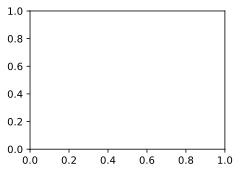

In [18]:
lr, num_epochs = 0.01, 10
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())